In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
from datetime import datetime

print("Imports complete")

Imports complete


## Load Pre-computed Occupancy Grid

Load the occupancy grid for collision checking.

In [22]:
# Load pre-computed occupancy grid
print("Loading pre-computed 2D occupancy grid...")
data_dir = Path('../data')

# Load the grid and metadata
occupancy_grid_full = np.load(data_dir / 'kitchen_occupancy_grid.npy')
metadata = np.load(data_dir / 'kitchen_occupancy_grid_metadata.npy', allow_pickle=True).item()

print(f"Loaded occupancy grid from disk")
print(f"  Grid shape: {occupancy_grid_full.shape}")
print(f"  Metadata: {metadata}")

# Extract grid parameters
grid_resolution = metadata.get('resolution', 0.1)
orig_x_min = metadata.get('x_min', -11.0)
orig_x_max = metadata.get('x_max', 1.0)
orig_y_min = metadata.get('y_min', -6.0)
orig_y_max = metadata.get('y_max', 6.0)

# Define interior region bounds
X_MIN, X_MAX = -7.7, -2.7
Y_MIN, Y_MAX = -3.0, 1.0
WAYPOINT_SPACING = 0.2

print(f"\nTest region: X=[{X_MIN}, {X_MAX}], Y=[{Y_MIN}, {Y_MAX}]")

# Crop grid to test bounds
orig_x_positions = np.arange(orig_x_min, orig_x_max, grid_resolution)
orig_y_positions = np.arange(orig_y_min, orig_y_max, grid_resolution)

x_start_idx = np.searchsorted(orig_x_positions, X_MIN)
x_end_idx = np.searchsorted(orig_x_positions, X_MAX)
y_start_idx = np.searchsorted(orig_y_positions, Y_MIN)
y_end_idx = np.searchsorted(orig_y_positions, Y_MAX)

occupancy_grid = occupancy_grid_full[y_start_idx:y_end_idx, x_start_idx:x_end_idx]

# Resample if needed
if abs(grid_resolution - WAYPOINT_SPACING) > 0.01:
    from scipy.ndimage import zoom
    scale_factor = grid_resolution / WAYPOINT_SPACING
    occupancy_grid = zoom(occupancy_grid, scale_factor, order=0).astype(np.uint8)

# Generate coordinate arrays
x_positions = np.arange(X_MIN, X_MAX, WAYPOINT_SPACING)
y_positions = np.arange(Y_MIN, Y_MAX, WAYPOINT_SPACING)

grid_width = len(x_positions)
grid_height = len(y_positions)

if occupancy_grid.shape != (grid_height, grid_width):
    from scipy.ndimage import zoom
    scale_y = grid_height / occupancy_grid.shape[0]
    scale_x = grid_width / occupancy_grid.shape[1]
    occupancy_grid = zoom(occupancy_grid, (scale_y, scale_x), order=0).astype(np.uint8)

print(f"\nOccupancy grid ready!")
print(f"  Grid size: {grid_width} x {grid_height}")
print(f"  Resolution: {WAYPOINT_SPACING}m")

# Store grid info
grid_info = {
    'occupancy_grid': occupancy_grid,
    'x_positions': x_positions,
    'y_positions': y_positions,
    'resolution': WAYPOINT_SPACING,
    'bounds': (X_MIN, X_MAX, Y_MIN, Y_MAX)
}

print("✓ Grid loaded and ready for testing")

Loading pre-computed 2D occupancy grid...
Loaded occupancy grid from disk
  Grid shape: (117, 222)
  Metadata: {'resolution': 0.05, 'x_min': np.float64(-10.455274), 'x_max': np.float64(0.598499), 'y_min': np.float64(-3.91422), 'y_max': np.float64(1.928361), 'width': 222, 'height': 117}

Test region: X=[-7.7, -2.7], Y=[-3.0, 1.0]

Occupancy grid ready!
  Grid size: 25 x 20
  Resolution: 0.2m
✓ Grid loaded and ready for testing


## RRT Planner Implementation

Implement the RRT planner class for path planning.

In [23]:
class RRTPlanner:
    """RRT path planner using occupancy grid for collision checking."""
    
    def __init__(self, grid_info, step_size=0.3, max_iterations=5000, goal_sample_rate=0.1):
        self.occupancy_grid = grid_info['occupancy_grid']
        self.x_positions = grid_info['x_positions']
        self.y_positions = grid_info['y_positions']
        self.resolution = grid_info['resolution']
        self.bounds = grid_info['bounds']
        self.x_min, self.x_max, self.y_min, self.y_max = self.bounds
        
        self.step_size = step_size
        self.max_iterations = max_iterations
        self.goal_sample_rate = goal_sample_rate
        
    def is_collision_free(self, x, y):
        """Check if a point is collision-free."""
        i = int((x - self.x_min) / self.resolution)
        j = int((y - self.y_min) / self.resolution)
        
        if i < 0 or i >= self.occupancy_grid.shape[1] or j < 0 or j >= self.occupancy_grid.shape[0]:
            return False
        
        return self.occupancy_grid[j, i] == 0
    
    def is_path_collision_free(self, p1, p2, num_checks=20):
        """Check if a straight line path is collision-free."""
        for i in range(num_checks + 1):
            t = i / num_checks
            x = p1[0] + t * (p2[0] - p1[0])
            y = p1[1] + t * (p2[1] - p1[1])
            
            if not self.is_collision_free(x, y):
                return False
        
        return True
    
    def sample_random_point(self):
        """Sample a random point in the search space."""
        x = random.uniform(self.x_min, self.x_max)
        y = random.uniform(self.y_min, self.y_max)
        return np.array([x, y])
    
    def get_nearest_node(self, tree, point):
        """Find the nearest node in the tree."""
        if len(tree) == 0:
            return None
        
        distances = [np.linalg.norm(node - point) for node in tree]
        return np.argmin(distances)
    
    def steer(self, from_point, to_point):
        """Steer from from_point toward to_point."""
        direction = to_point - from_point
        distance = np.linalg.norm(direction)
        
        if distance <= self.step_size:
            return to_point
        else:
            return from_point + (direction / distance) * self.step_size
    
    def plan(self, start, goal, verbose=False):
        """Plan a path from start to goal using RRT."""
        start = np.array(start)
        goal = np.array(goal)
        
        # Check validity
        if not self.is_collision_free(start[0], start[1]):
            if verbose:
                print(f"Start position {start} is in collision!")
            return None, 0
        
        if not self.is_collision_free(goal[0], goal[1]):
            if verbose:
                print(f"Goal position {goal} is in collision!")
            return None, 0
        
        # Initialize tree
        tree = [start]
        parent = {0: None}
        
        for iteration in range(self.max_iterations):
            # Sample
            if random.random() < self.goal_sample_rate:
                sample = goal
            else:
                sample = self.sample_random_point()
            
            # Find nearest
            nearest_idx = self.get_nearest_node(tree, sample)
            nearest = tree[nearest_idx]
            
            # Steer
            new_point = self.steer(nearest, sample)
            
            # Check collision
            if self.is_path_collision_free(nearest, new_point):
                new_idx = len(tree)
                tree.append(new_point)
                parent[new_idx] = nearest_idx
                
                # Check if goal reached
                if np.linalg.norm(new_point - goal) < self.step_size:
                    if self.is_path_collision_free(new_point, goal):
                        goal_idx = len(tree)
                        tree.append(goal)
                        parent[goal_idx] = new_idx
                        
                        # Reconstruct path
                        path = []
                        current = goal_idx
                        while current is not None:
                            path.append(tuple(tree[current]))
                            current = parent[current]
                        
                        path.reverse()
                        
                        if verbose:
                            print(f"Found path with {len(path)} nodes in {iteration + 1} iterations")
                        
                        return path, iteration + 1
        
        if verbose:
            print(f"Failed to find path after {self.max_iterations} iterations")
        return None, self.max_iterations

print("✓ RRT planner class defined")

✓ RRT planner class defined


## Generate Test Waypoint Pairs

Generate source-goal waypoint pairs distributed across the kitchen layout.

In [24]:
def generate_random_free_point(grid_info, max_attempts=100):
    """Generate a random collision-free point."""
    occupancy_grid = grid_info['occupancy_grid']
    x_positions = grid_info['x_positions']
    y_positions = grid_info['y_positions']
    
    for _ in range(max_attempts):
        i = random.randint(0, len(x_positions) - 1)
        j = random.randint(0, len(y_positions) - 1)
        
        if occupancy_grid[j, i] == 0:
            return (x_positions[i], y_positions[j])
    
    return None

def generate_waypoint_pairs(grid_info, num_pairs=10, min_distance=2.0):
    """Generate waypoint pairs with minimum distance requirement."""
    pairs = []
    
    for i in range(num_pairs):
        attempts = 0
        max_attempts = 50
        
        while attempts < max_attempts:
            start = generate_random_free_point(grid_info)
            goal = generate_random_free_point(grid_info)
            
            if start is None or goal is None:
                attempts += 1
                continue
            
            distance = np.linalg.norm(np.array(goal) - np.array(start))
            
            if distance >= min_distance:
                pairs.append((start, goal))
                break
            
            attempts += 1
        
        if attempts >= max_attempts:
            print(f"Warning: Could not generate pair {i+1} with minimum distance")
    
    return pairs

# Generate test waypoint pairs
NUM_TEST_PAIRS = 15
MIN_DISTANCE = 2.5  # meters

print(f"Generating {NUM_TEST_PAIRS} test waypoint pairs...")
waypoint_pairs = generate_waypoint_pairs(grid_info, NUM_TEST_PAIRS, MIN_DISTANCE)

print(f"\n✓ Generated {len(waypoint_pairs)} waypoint pairs")
print("\nTest pairs:")
for i, (start, goal) in enumerate(waypoint_pairs):
    dist = np.linalg.norm(np.array(goal) - np.array(start))
    print(f"  Pair {i+1}: ({start[0]:.2f}, {start[1]:.2f}) → ({goal[0]:.2f}, {goal[1]:.2f}) [dist={dist:.2f}m]")

Generating 15 test waypoint pairs...

✓ Generated 15 waypoint pairs

Test pairs:
  Pair 1: (-3.90, -0.40) → (-7.10, 0.60) [dist=3.35m]
  Pair 2: (-6.90, -0.80) → (-4.30, -2.60) [dist=3.16m]
  Pair 3: (-6.50, -2.40) → (-5.70, 0.20) [dist=2.72m]
  Pair 4: (-5.70, -3.00) → (-4.30, -0.80) [dist=2.61m]
  Pair 5: (-6.70, 0.60) → (-6.30, -2.00) [dist=2.63m]
  Pair 6: (-7.30, -1.40) → (-4.70, -2.40) [dist=2.79m]
  Pair 7: (-3.90, -2.20) → (-4.50, 0.60) [dist=2.86m]
  Pair 8: (-6.70, -0.80) → (-4.30, 0.20) [dist=2.60m]
  Pair 9: (-4.10, -2.80) → (-4.50, 0.60) [dist=3.42m]
  Pair 10: (-5.70, 0.20) → (-3.90, -2.20) [dist=3.00m]
  Pair 11: (-6.70, 0.20) → (-6.30, -2.80) [dist=3.03m]
  Pair 12: (-6.30, 0.40) → (-5.10, -2.80) [dist=3.42m]
  Pair 13: (-6.90, -2.20) → (-3.70, 0.00) [dist=3.88m]
  Pair 14: (-3.30, -0.20) → (-7.50, 0.00) [dist=4.20m]
  Pair 15: (-5.10, 0.20) → (-4.90, -2.80) [dist=3.01m]


## Run RRT Tests

Run RRT path planning for all waypoint pairs and collect statistics.

In [25]:
# Create RRT planner
rrt = RRTPlanner(grid_info, step_size=0.3, max_iterations=5000, goal_sample_rate=0.15)

# Run tests
print("="*70)
print("Running RRT Path Planning Tests")
print("="*70)

results = []

for i, (start, goal) in enumerate(waypoint_pairs):
    print(f"\nTest {i+1}/{len(waypoint_pairs)}: ({start[0]:.2f}, {start[1]:.2f}) → ({goal[0]:.2f}, {goal[1]:.2f})")
    
    # Plan path
    path, iterations = rrt.plan(start, goal, verbose=False)
    
    # Calculate metrics
    if path is not None:
        # Path length
        path_length = 0
        for j in range(len(path) - 1):
            p1 = np.array(path[j])
            p2 = np.array(path[j+1])
            path_length += np.linalg.norm(p2 - p1)
        
        # Straight line distance
        straight_dist = np.linalg.norm(np.array(goal) - np.array(start))
        
        # Path efficiency (ratio of straight line to actual path)
        efficiency = straight_dist / path_length if path_length > 0 else 0
        
        result = {
            'test_id': i + 1,
            'start': start,
            'goal': goal,
            'success': True,
            'path': path,
            'num_waypoints': len(path),
            'iterations': iterations,
            'path_length': path_length,
            'straight_distance': straight_dist,
            'efficiency': efficiency
        }
        
        print(f"  ✓ SUCCESS")
        print(f"    Path: {len(path)} waypoints, {path_length:.2f}m")
        print(f"    Iterations: {iterations}")
        print(f"    Efficiency: {efficiency:.2%} (straight={straight_dist:.2f}m)")
    else:
        result = {
            'test_id': i + 1,
            'start': start,
            'goal': goal,
            'success': False,
            'path': None,
            'num_waypoints': 0,
            'iterations': iterations,
            'path_length': 0,
            'straight_distance': np.linalg.norm(np.array(goal) - np.array(start)),
            'efficiency': 0
        }
        
        print(f"  ✗ FAILED after {iterations} iterations")
    
    results.append(result)

# Calculate statistics
successful_tests = [r for r in results if r['success']]
failed_tests = [r for r in results if not r['success']]

print("\n" + "="*70)
print("Test Summary")
print("="*70)
print(f"Total tests: {len(results)}")
print(f"Successful: {len(successful_tests)} ({len(successful_tests)/len(results)*100:.1f}%)")
print(f"Failed: {len(failed_tests)} ({len(failed_tests)/len(results)*100:.1f}%)")

if successful_tests:
    avg_waypoints = np.mean([r['num_waypoints'] for r in successful_tests])
    avg_iterations = np.mean([r['iterations'] for r in successful_tests])
    avg_path_length = np.mean([r['path_length'] for r in successful_tests])
    avg_efficiency = np.mean([r['efficiency'] for r in successful_tests])
    
    print(f"\nSuccessful paths statistics:")
    print(f"  Average waypoints: {avg_waypoints:.1f}")
    print(f"  Average iterations: {avg_iterations:.1f}")
    print(f"  Average path length: {avg_path_length:.2f}m")
    print(f"  Average efficiency: {avg_efficiency:.2%}")

print("\n✓ RRT testing complete")

Running RRT Path Planning Tests

Test 1/15: (-3.90, -0.40) → (-7.10, 0.60)
  ✓ SUCCESS
    Path: 15 waypoints, 3.97m
    Iterations: 66
    Efficiency: 84.53% (straight=3.35m)

Test 2/15: (-6.90, -0.80) → (-4.30, -2.60)
  ✓ SUCCESS
    Path: 21 waypoints, 5.92m
    Iterations: 64
    Efficiency: 53.38% (straight=3.16m)

Test 3/15: (-6.50, -2.40) → (-5.70, 0.20)
  ✓ SUCCESS
    Path: 12 waypoints, 3.08m
    Iterations: 30
    Efficiency: 88.33% (straight=2.72m)

Test 4/15: (-5.70, -3.00) → (-4.30, -0.80)
  ✓ SUCCESS
    Path: 14 waypoints, 3.80m
    Iterations: 42
    Efficiency: 68.65% (straight=2.61m)

Test 5/15: (-6.70, 0.60) → (-6.30, -2.00)
  ✓ SUCCESS
    Path: 12 waypoints, 3.13m
    Iterations: 31
    Efficiency: 83.92% (straight=2.63m)

Test 6/15: (-7.30, -1.40) → (-4.70, -2.40)
  ✓ SUCCESS
    Path: 14 waypoints, 3.75m
    Iterations: 90
    Efficiency: 74.21% (straight=2.79m)

Test 7/15: (-3.90, -2.20) → (-4.50, 0.60)
  ✓ SUCCESS
    Path: 12 waypoints, 3.17m
    Iterations: 

  ✓ SUCCESS
    Path: 19 waypoints, 5.26m
    Iterations: 179
    Efficiency: 64.94% (straight=3.42m)

Test 13/15: (-6.90, -2.20) → (-3.70, 0.00)
  ✓ SUCCESS
    Path: 20 waypoints, 5.54m
    Iterations: 63
    Efficiency: 70.05% (straight=3.88m)

Test 14/15: (-3.30, -0.20) → (-7.50, 0.00)
  ✓ SUCCESS
    Path: 18 waypoints, 4.93m
    Iterations: 29
    Efficiency: 85.24% (straight=4.20m)

Test 15/15: (-5.10, 0.20) → (-4.90, -2.80)
  ✓ SUCCESS
    Path: 18 waypoints, 4.77m
    Iterations: 97
    Efficiency: 63.04% (straight=3.01m)

Test Summary
Total tests: 15
Successful: 15 (100.0%)
Failed: 0 (0.0%)

Successful paths statistics:
  Average waypoints: 15.8
  Average iterations: 65.6
  Average path length: 4.28m
  Average efficiency: 75.28%

✓ RRT testing complete
  ✓ SUCCESS
    Path: 18 waypoints, 4.77m
    Iterations: 97
    Efficiency: 63.04% (straight=3.01m)

Test Summary
Total tests: 15
Successful: 15 (100.0%)
Failed: 0 (0.0%)

Successful paths statistics:
  Average waypoints: 15.8

## Visualize All Test Paths

Display all successful paths on the occupancy grid.

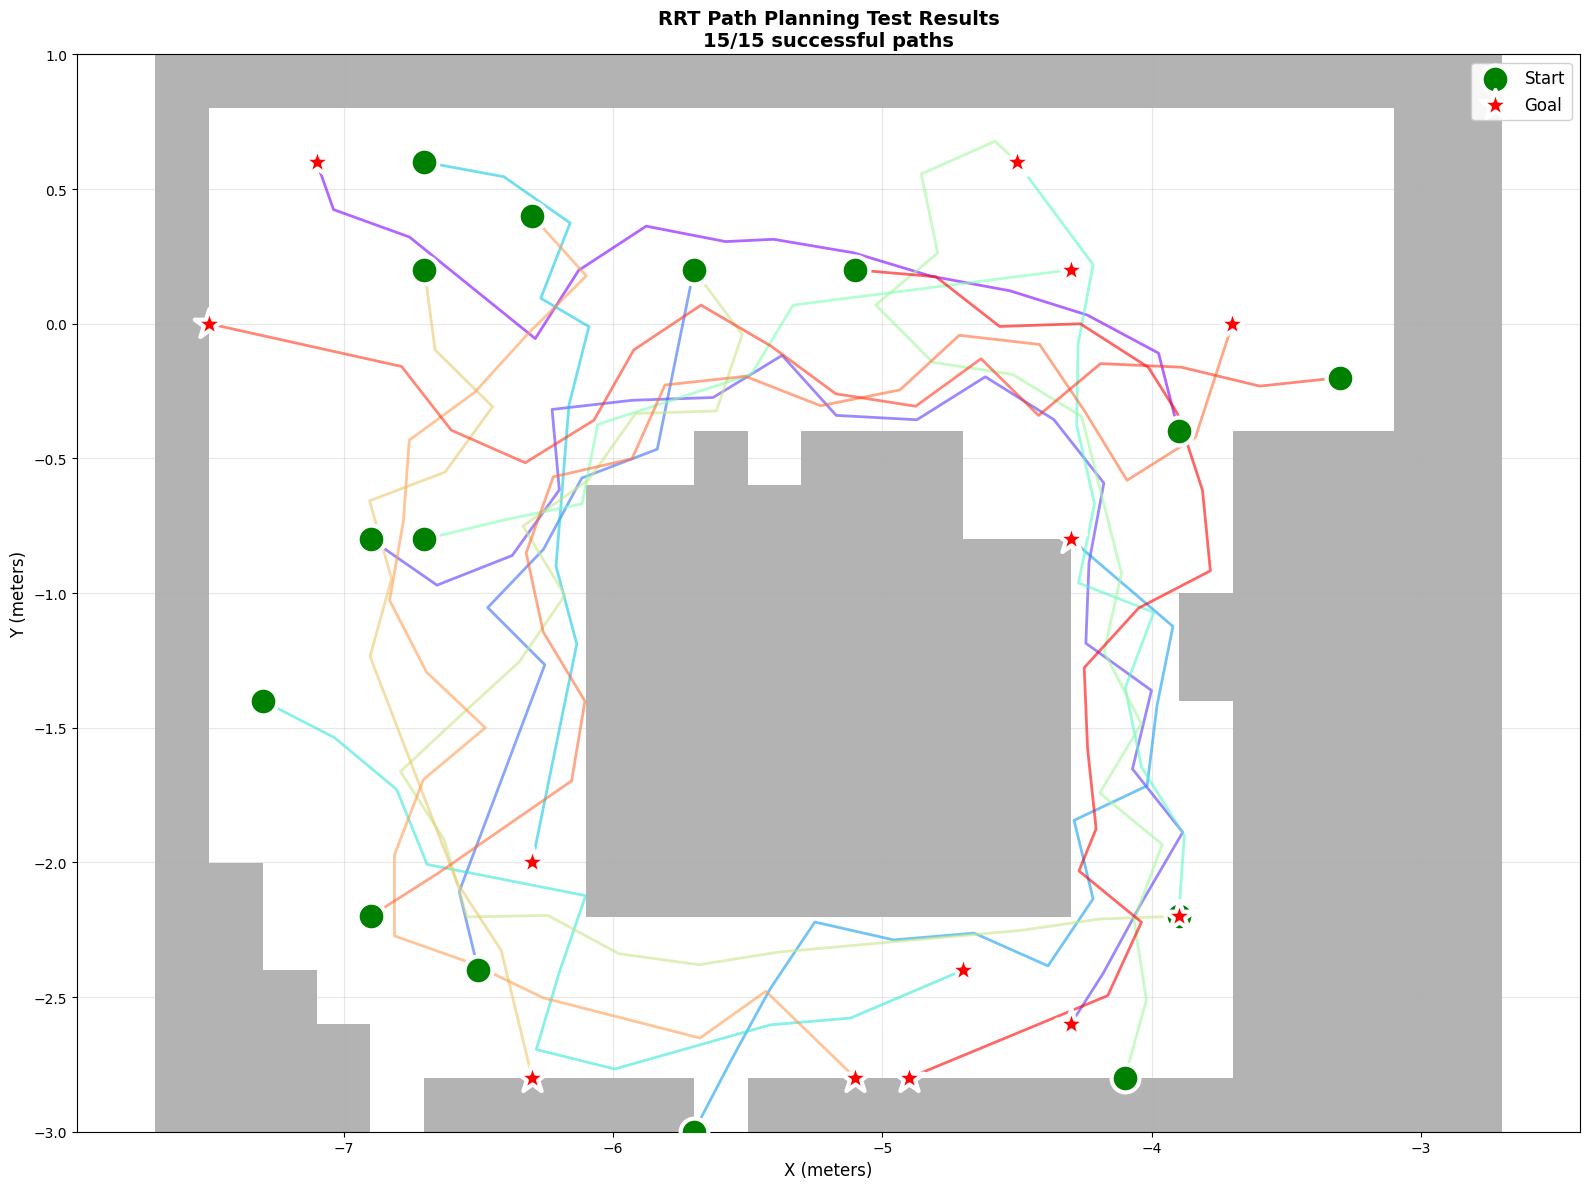

✓ Visualization complete


In [26]:
# Visualize all paths
plt.figure(figsize=(16, 12))

# Plot occupancy grid
plt.imshow(occupancy_grid, cmap='gray_r', origin='lower', 
           extent=[X_MIN, X_MAX, Y_MIN, Y_MAX], 
           alpha=0.3, interpolation='nearest')

# Plot all successful paths
colors = plt.cm.rainbow(np.linspace(0, 1, len(successful_tests)))

# Track if we've added legend labels
added_start_label = False
added_goal_label = False
added_failed_label = False

for i, result in enumerate(successful_tests):
    path_array = np.array(result['path'])
    # Plot path without label
    plt.plot(path_array[:, 0], path_array[:, 1], 
             color=colors[i], linewidth=2, alpha=0.6)
    
    # Mark start and goal with larger markers
    if not added_start_label:
        plt.scatter(result['start'][0], result['start'][1], 
                    c='green', s=400, marker='o', 
                    edgecolors='white', linewidths=3, zorder=10, label='Start')
        added_start_label = True
    else:
        plt.scatter(result['start'][0], result['start'][1], 
                    c='green', s=400, marker='o', 
                    edgecolors='white', linewidths=3, zorder=10)
    
    if not added_goal_label:
        plt.scatter(result['goal'][0], result['goal'][1], 
                    c='red', s=500, marker='*', 
                    edgecolors='white', linewidths=3, zorder=10, label='Goal')
        added_goal_label = True
    else:
        plt.scatter(result['goal'][0], result['goal'][1], 
                    c='red', s=500, marker='*', 
                    edgecolors='white', linewidths=3, zorder=10)

# Plot failed test points
for result in failed_tests:
    plt.plot([result['start'][0], result['goal'][0]], 
             [result['start'][1], result['goal'][1]], 
             'r--', alpha=0.3, linewidth=1)
    
    if not added_failed_label:
        plt.scatter(result['start'][0], result['start'][1], 
                    c='orange', s=300, marker='x', linewidths=3, zorder=10, label='Failed')
        plt.scatter(result['goal'][0], result['goal'][1], 
                    c='orange', s=300, marker='x', linewidths=3, zorder=10)
        added_failed_label = True
    else:
        plt.scatter(result['start'][0], result['start'][1], 
                    c='orange', s=300, marker='x', linewidths=3, zorder=10)
        plt.scatter(result['goal'][0], result['goal'][1], 
                    c='orange', s=300, marker='x', linewidths=3, zorder=10)

plt.xlim(X_MIN, X_MAX)
plt.ylim(Y_MIN, Y_MAX)
plt.xlabel('X (meters)', fontsize=12)
plt.ylabel('Y (meters)', fontsize=12)
plt.title(f'RRT Path Planning Test Results\n{len(successful_tests)}/{len(results)} successful paths', 
          fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

print("✓ Visualization complete")

## Detailed Path Statistics

Analyze path statistics with histograms.

## Smooth Paths and Visualize

Apply path smoothing using shortcutting and interpolation, then visualize the smoothed paths.

In [27]:
from scipy.interpolate import splprep, splev

def shortcut_path(path, grid_info, max_iterations=100):
    """Smooth path by creating shortcuts between non-adjacent waypoints."""
    if len(path) < 3:
        return path
    
    occupancy_grid = grid_info['occupancy_grid']
    resolution = grid_info['resolution']
    x_min, x_max, y_min, y_max = grid_info['bounds']
    
    def is_path_clear(p1, p2, num_checks=30):
        """Check if straight line path is collision-free."""
        for i in range(num_checks + 1):
            t = i / num_checks
            x = p1[0] + t * (p2[0] - p1[0])
            y = p1[1] + t * (p2[1] - p1[1])
            
            grid_i = int((x - x_min) / resolution)
            grid_j = int((y - y_min) / resolution)
            
            if grid_i < 0 or grid_i >= occupancy_grid.shape[1] or \
               grid_j < 0 or grid_j >= occupancy_grid.shape[0]:
                return False
            
            if occupancy_grid[grid_j, grid_i] != 0:
                return False
        
        return True
    
    smoothed = list(path)
    
    for _ in range(max_iterations):
        if len(smoothed) < 3:
            break
        
        i = random.randint(0, len(smoothed) - 3)
        j = random.randint(i + 2, len(smoothed) - 1)
        
        if is_path_clear(smoothed[i], smoothed[j]):
            smoothed = smoothed[:i+1] + smoothed[j:]
    
    return smoothed


def smooth_path_with_spline(path, grid_info, num_points=200):
    """
    Smooth path using B-spline interpolation with smoothing parameter to create smooth curves.
    
    Args:
        path: List of waypoints
        grid_info: Grid information for collision checking
        num_points: Number of points to generate along the spline
    
    Returns:
        Smoothed path with collision-free spline curve
    """
    if len(path) < 3:
        return path
    
    occupancy_grid = grid_info['occupancy_grid']
    resolution = grid_info['resolution']
    x_min, x_max, y_min, y_max = grid_info['bounds']
    
    # Convert path to numpy array
    path_array = np.array(path)
    
    # Calculate total path length for smoothing parameter
    path_length = 0
    for i in range(len(path) - 1):
        path_length += np.linalg.norm(path_array[i+1] - path_array[i])
    
    # Fit B-spline to the path with smoothing
    # s parameter controls smoothness: larger s = smoother curve (may not pass through all points)
    # This helps avoid sharp corners
    smoothing_factor = path_length * 0.05  # Adaptive smoothing based on path length
    
    try:
        # Try with cubic spline and smoothing
        tck, u = splprep([path_array[:, 0], path_array[:, 1]], 
                         s=smoothing_factor,  # Non-zero smoothing to avoid sharp corners
                         k=min(3, len(path)-1))  # Cubic spline
    except Exception as e:
        print(f"  Warning: Spline fitting failed ({e}), using shortcut path")
        return path
    
    # Evaluate spline at many points to get smooth curve
    u_new = np.linspace(0, 1, num_points)
    smooth_coords = splev(u_new, tck)
    
    # Check if spline path is collision-free
    def is_collision_free(x, y):
        grid_i = int((x - x_min) / resolution)
        grid_j = int((y - y_min) / resolution)
        
        if grid_i < 0 or grid_i >= occupancy_grid.shape[1] or \
           grid_j < 0 or grid_j >= occupancy_grid.shape[0]:
            return False
        
        return occupancy_grid[grid_j, grid_i] == 0
    
    # Check all points along spline
    smooth_path = []
    collision_count = 0
    
    for i in range(num_points):
        x, y = smooth_coords[0][i], smooth_coords[1][i]
        
        # Count collisions
        if not is_collision_free(x, y):
            collision_count += 1
        else:
            smooth_path.append((x, y))
    
    # If too many collisions (>5% of points), fall back to shortcut path
    if collision_count > num_points * 0.05:
        print(f"  Warning: Spline has {collision_count} collisions, using shortcut path instead")
        return path
    
    # If we have a valid smooth path, return it
    if len(smooth_path) > 10:
        return smooth_path
    else:
        return path


# Smooth all successful paths
print("Smoothing all successful paths with B-spline curves...")
print("Using adaptive smoothing to avoid sharp corners...\n")
smoothed_results = []

for idx, result in enumerate(successful_tests):
    original_path = result['path']
    
    print(f"Processing path {idx+1}/{len(successful_tests)} (Test {result['test_id']})")
    
    # Apply shortcutting to reduce waypoints
    shortcut = shortcut_path(original_path, grid_info, max_iterations=200)
    print(f"  Shortcut: {len(original_path)} → {len(shortcut)} waypoints")
    
    # Apply B-spline smoothing to create smooth curves
    smooth = smooth_path_with_spline(shortcut, grid_info, num_points=200)
    print(f"  Smoothed: {len(smooth)} points")
    
    # Calculate smoothed path length
    smooth_length = 0
    for i in range(len(smooth) - 1):
        p1 = np.array(smooth[i])
        p2 = np.array(smooth[i+1])
        smooth_length += np.linalg.norm(p2 - p1)
    
    smoothed_result = {
        'test_id': result['test_id'],
        'start': result['start'],
        'goal': result['goal'],
        'original_path': original_path,
        'shortcut_path': shortcut,
        'smooth_path': smooth,
        'original_length': result['path_length'],
        'smooth_length': smooth_length,
        'original_waypoints': len(original_path),
        'smooth_waypoints': len(smooth),
        'reduction': (1 - smooth_length / result['path_length']) * 100
    }
    smoothed_results.append(smoothed_result)

print(f"\n{'='*60}")
print(f"✓ Smoothed {len(smoothed_results)} paths using B-spline curves")
print(f"{'='*60}")
print(f"\nSmoothing statistics:")
avg_reduction = np.mean([r['reduction'] for r in smoothed_results])
avg_original_waypoints = np.mean([r['original_waypoints'] for r in smoothed_results])
avg_smooth_waypoints = np.mean([r['smooth_waypoints'] for r in smoothed_results])
print(f"  Average path length reduction: {avg_reduction:.1f}%")
print(f"  Average original waypoints: {avg_original_waypoints:.1f}")
print(f"  Average smooth waypoints: {avg_smooth_waypoints:.1f}")

Smoothing all successful paths with B-spline curves...
Using adaptive smoothing to avoid sharp corners...

Processing path 1/15 (Test 1)
  Shortcut: 15 → 2 waypoints
  Smoothed: 2 points
Processing path 2/15 (Test 2)
  Shortcut: 21 → 5 waypoints
  Smoothed: 200 points
Processing path 3/15 (Test 3)
  Shortcut: 12 → 3 waypoints
  Smoothed: 200 points
Processing path 4/15 (Test 4)
  Shortcut: 14 → 5 waypoints
  Smoothed: 198 points
Processing path 5/15 (Test 5)
  Shortcut: 12 → 2 waypoints
  Smoothed: 2 points
Processing path 6/15 (Test 6)
  Shortcut: 14 → 3 waypoints
  Smoothed: 200 points
Processing path 7/15 (Test 7)
  Shortcut: 12 → 2 waypoints
  Smoothed: 2 points
Processing path 8/15 (Test 8)
  Shortcut: 11 → 2 waypoints
  Smoothed: 2 points
Processing path 9/15 (Test 9)
  Shortcut: 17 → 3 waypoints
  Smoothed: 200 points
Processing path 10/15 (Test 10)
  Shortcut: 21 → 4 waypoints
  Smoothed: 4 points
Processing path 11/15 (Test 11)
  Shortcut: 13 → 2 waypoints
  Smoothed: 2 points

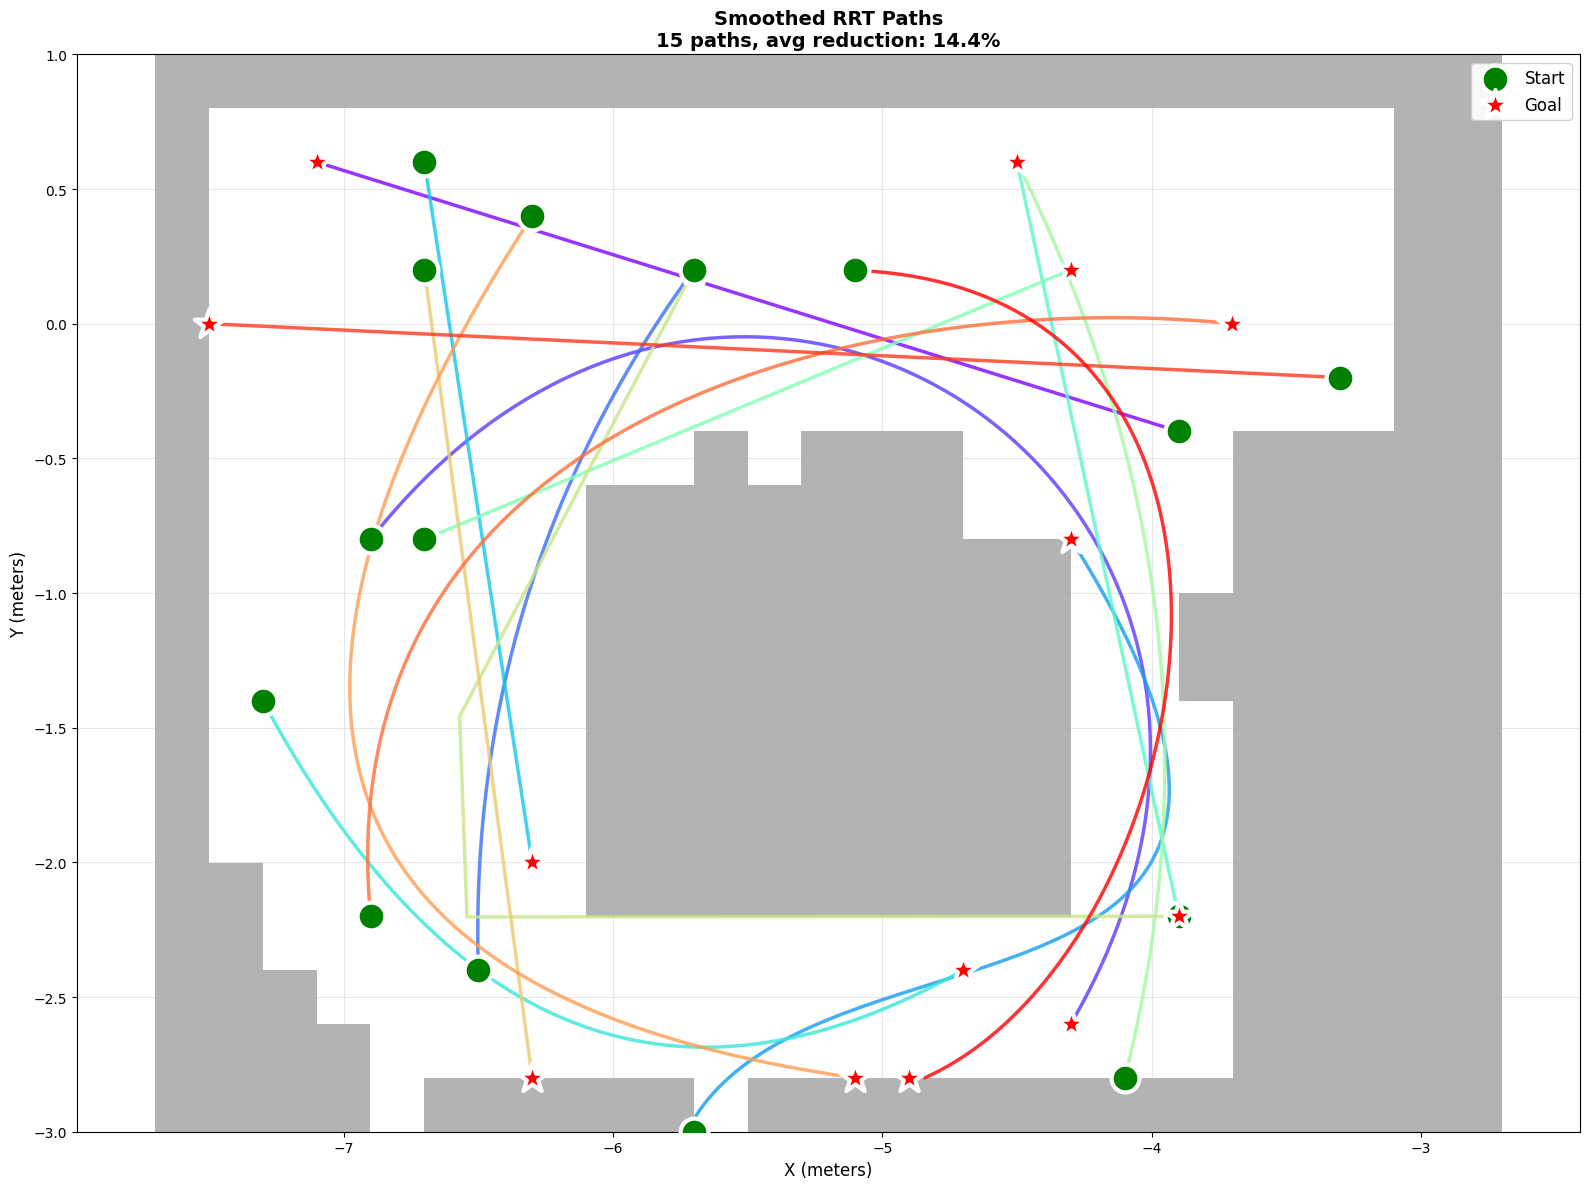

✓ Smoothed path visualization complete


In [28]:
# Visualize smoothed paths
plt.figure(figsize=(16, 12))

# Plot occupancy grid
plt.imshow(occupancy_grid, cmap='gray_r', origin='lower', 
           extent=[X_MIN, X_MAX, Y_MIN, Y_MAX], 
           alpha=0.3, interpolation='nearest')

# Plot all smoothed paths
colors = plt.cm.rainbow(np.linspace(0, 1, len(smoothed_results)))

# Track legend labels
added_start_label = False
added_goal_label = False

for i, result in enumerate(smoothed_results):
    smooth_array = np.array(result['smooth_path'])
    
    # Plot smooth path
    plt.plot(smooth_array[:, 0], smooth_array[:, 1], 
             color=colors[i], linewidth=2.5, alpha=0.8)
    
    # Mark start and goal
    if not added_start_label:
        plt.scatter(result['start'][0], result['start'][1], 
                    c='green', s=400, marker='o', 
                    edgecolors='white', linewidths=3, zorder=10, label='Start')
        added_start_label = True
    else:
        plt.scatter(result['start'][0], result['start'][1], 
                    c='green', s=400, marker='o', 
                    edgecolors='white', linewidths=3, zorder=10)
    
    if not added_goal_label:
        plt.scatter(result['goal'][0], result['goal'][1], 
                    c='red', s=500, marker='*', 
                    edgecolors='white', linewidths=3, zorder=10, label='Goal')
        added_goal_label = True
    else:
        plt.scatter(result['goal'][0], result['goal'][1], 
                    c='red', s=500, marker='*', 
                    edgecolors='white', linewidths=3, zorder=10)

plt.xlim(X_MIN, X_MAX)
plt.ylim(Y_MIN, Y_MAX)
plt.xlabel('X (meters)', fontsize=12)
plt.ylabel('Y (meters)', fontsize=12)
plt.title(f'Smoothed RRT Paths\n{len(smoothed_results)} paths, avg reduction: {avg_reduction:.1f}%', 
          fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

print("✓ Smoothed path visualization complete")

## Compare Original vs Smoothed Paths

Side-by-side comparison of original RRT paths and smoothed versions.

## Linear Interpolation Smoothing (Without B-spline)

Apply simple linear interpolation smoothing without using B-spline curves.

In [29]:
def interpolate_path_linear(path, interpolation_step=0.08):
    """
    Interpolate path with fine resolution using linear interpolation.
    Creates more points between waypoints but keeps straight line segments.
    """
    if len(path) < 2:
        return path
    
    interpolated = []
    
    for i in range(len(path) - 1):
        p1 = np.array(path[i])
        p2 = np.array(path[i + 1])
        
        dist = np.linalg.norm(p2 - p1)
        num_points = max(int(dist / interpolation_step), 1)
        
        for j in range(num_points):
            t = j / num_points
            pt = p1 + t * (p2 - p1)
            interpolated.append(tuple(pt))
    
    interpolated.append(path[-1])
    return interpolated


# Apply linear interpolation smoothing to all successful paths
print("Applying linear interpolation smoothing (without B-spline)...")
linear_smoothed_results = []

for result in successful_tests:
    original_path = result['path']
    
    # Apply shortcutting to reduce waypoints
    shortcut = shortcut_path(original_path, grid_info, max_iterations=200)
    
    # Apply linear interpolation (no curves, just more points)
    linear_smooth = interpolate_path_linear(shortcut, interpolation_step=0.08)
    
    # Calculate smoothed path length
    linear_length = 0
    for i in range(len(linear_smooth) - 1):
        p1 = np.array(linear_smooth[i])
        p2 = np.array(linear_smooth[i+1])
        linear_length += np.linalg.norm(p2 - p1)
    
    linear_result = {
        'test_id': result['test_id'],
        'start': result['start'],
        'goal': result['goal'],
        'original_path': original_path,
        'shortcut_path': shortcut,
        'linear_smooth_path': linear_smooth,
        'original_length': result['path_length'],
        'linear_length': linear_length,
        'original_waypoints': len(original_path),
        'linear_waypoints': len(linear_smooth),
        'reduction': (1 - linear_length / result['path_length']) * 100
    }
    linear_smoothed_results.append(linear_result)

print(f"✓ Applied linear interpolation to {len(linear_smoothed_results)} paths")
print(f"\nLinear interpolation statistics:")
avg_linear_reduction = np.mean([r['reduction'] for r in linear_smoothed_results])
avg_linear_waypoints = np.mean([r['linear_waypoints'] for r in linear_smoothed_results])
print(f"  Average path length reduction: {avg_linear_reduction:.1f}%")
print(f"  Average interpolated waypoints: {avg_linear_waypoints:.1f}")

Applying linear interpolation smoothing (without B-spline)...
✓ Applied linear interpolation to 15 paths

Linear interpolation statistics:
  Average path length reduction: 14.0%
  Average interpolated waypoints: 45.7


## Compare All Three Methods

Compare original RRT paths, linear interpolation, and B-spline smoothing side by side.

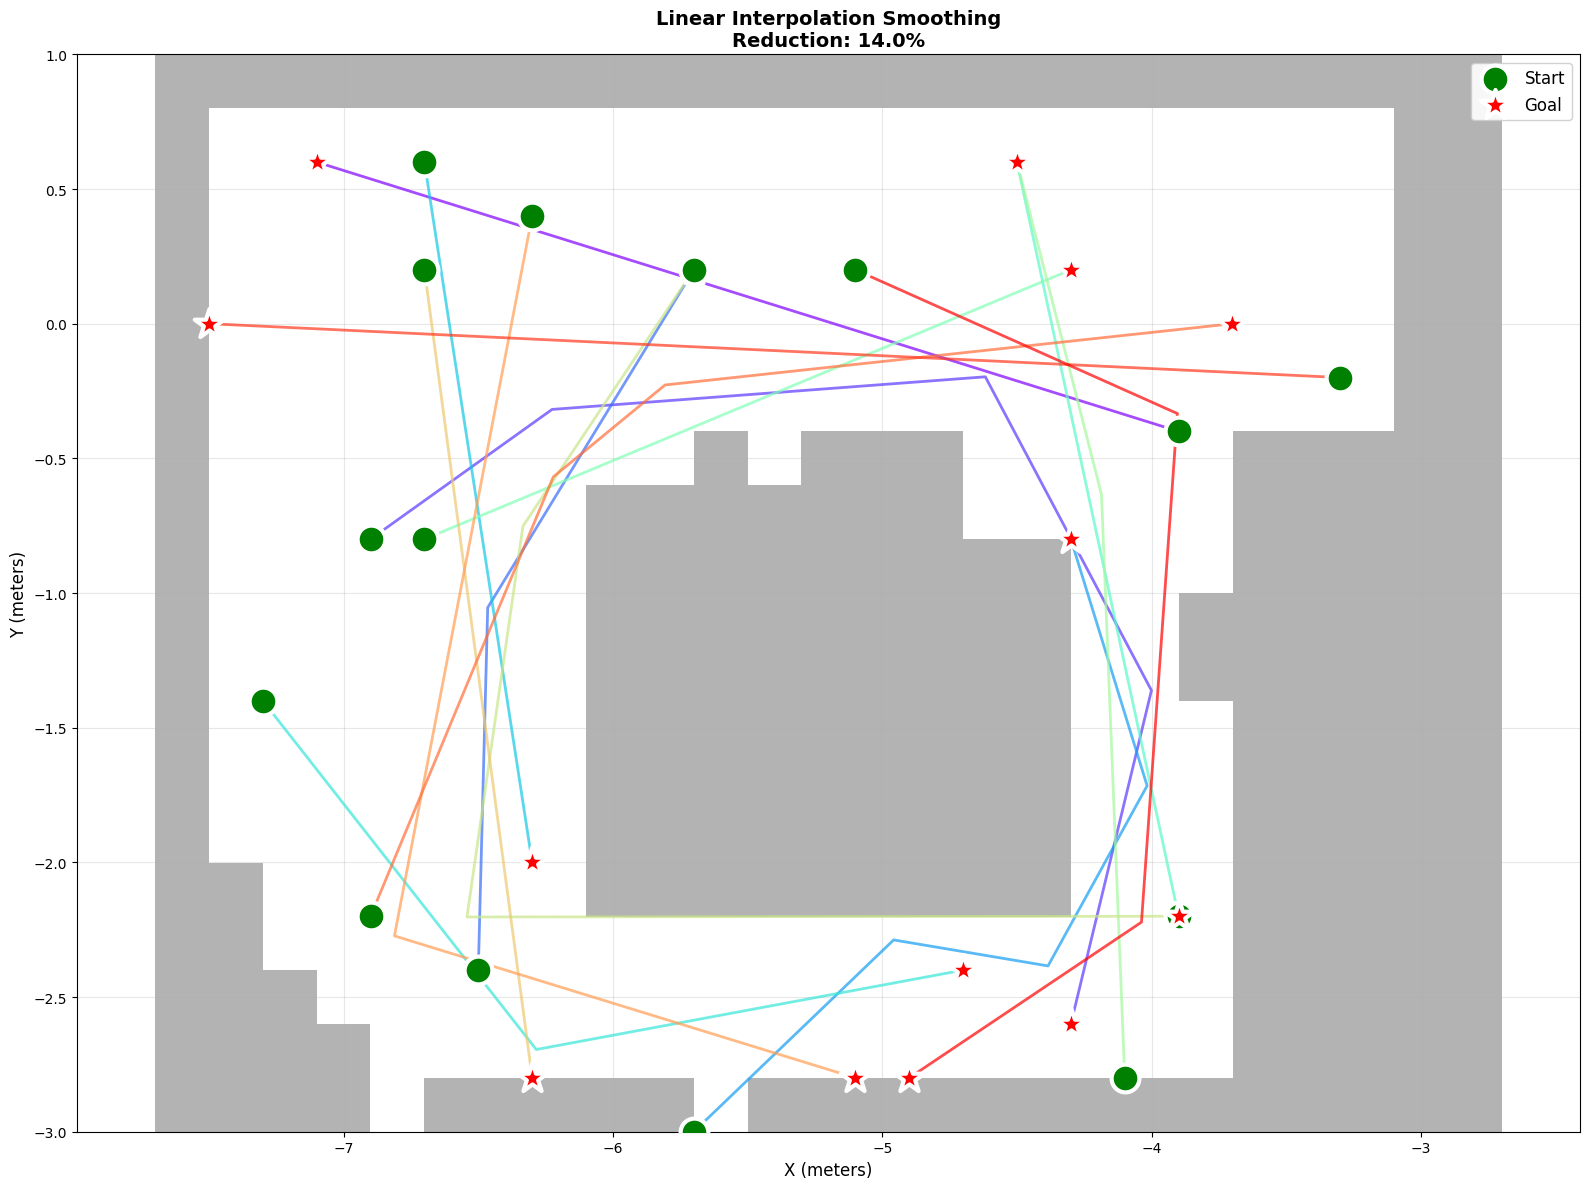

✓ Linear interpolation visualization complete

Summary:
  Average waypoints: 45.7
  Average path length reduction: 14.0%


In [35]:
# Visualize linear interpolation smoothing
plt.figure(figsize=(16, 12))

# Plot occupancy grid
plt.imshow(occupancy_grid, cmap='gray_r', origin='lower', 
           extent=[X_MIN, X_MAX, Y_MIN, Y_MAX], 
           alpha=0.3, interpolation='nearest')

# Plot linear interpolated paths
colors = plt.cm.rainbow(np.linspace(0, 1, len(linear_smoothed_results)))

added_start = False
added_goal = False

for i, result in enumerate(linear_smoothed_results):
    linear_array = np.array(result['linear_smooth_path'])
    plt.plot(linear_array[:, 0], linear_array[:, 1], 
             color=colors[i], linewidth=2, alpha=0.7)
    
    if not added_start:
        plt.scatter(result['start'][0], result['start'][1], 
                    c='green', s=400, marker='o', 
                    edgecolors='white', linewidths=3, zorder=10, label='Start')
        added_start = True
    else:
        plt.scatter(result['start'][0], result['start'][1], 
                    c='green', s=400, marker='o', 
                    edgecolors='white', linewidths=3, zorder=10)
    
    if not added_goal:
        plt.scatter(result['goal'][0], result['goal'][1], 
                    c='red', s=500, marker='*', 
                    edgecolors='white', linewidths=3, zorder=10, label='Goal')
        added_goal = True
    else:
        plt.scatter(result['goal'][0], result['goal'][1], 
                    c='red', s=500, marker='*', 
                    edgecolors='white', linewidths=3, zorder=10)

plt.xlim(X_MIN, X_MAX)
plt.ylim(Y_MIN, Y_MAX)
plt.xlabel('X (meters)', fontsize=12)
plt.ylabel('Y (meters)', fontsize=12)
plt.title(f'Linear Interpolation Smoothing\nReduction: {avg_linear_reduction:.1f}%', 
          fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

print("✓ Linear interpolation visualization complete")
print(f"\nSummary:")
print(f"  Average waypoints: {avg_linear_waypoints:.1f}")
print(f"  Average path length reduction: {avg_linear_reduction:.1f}%")

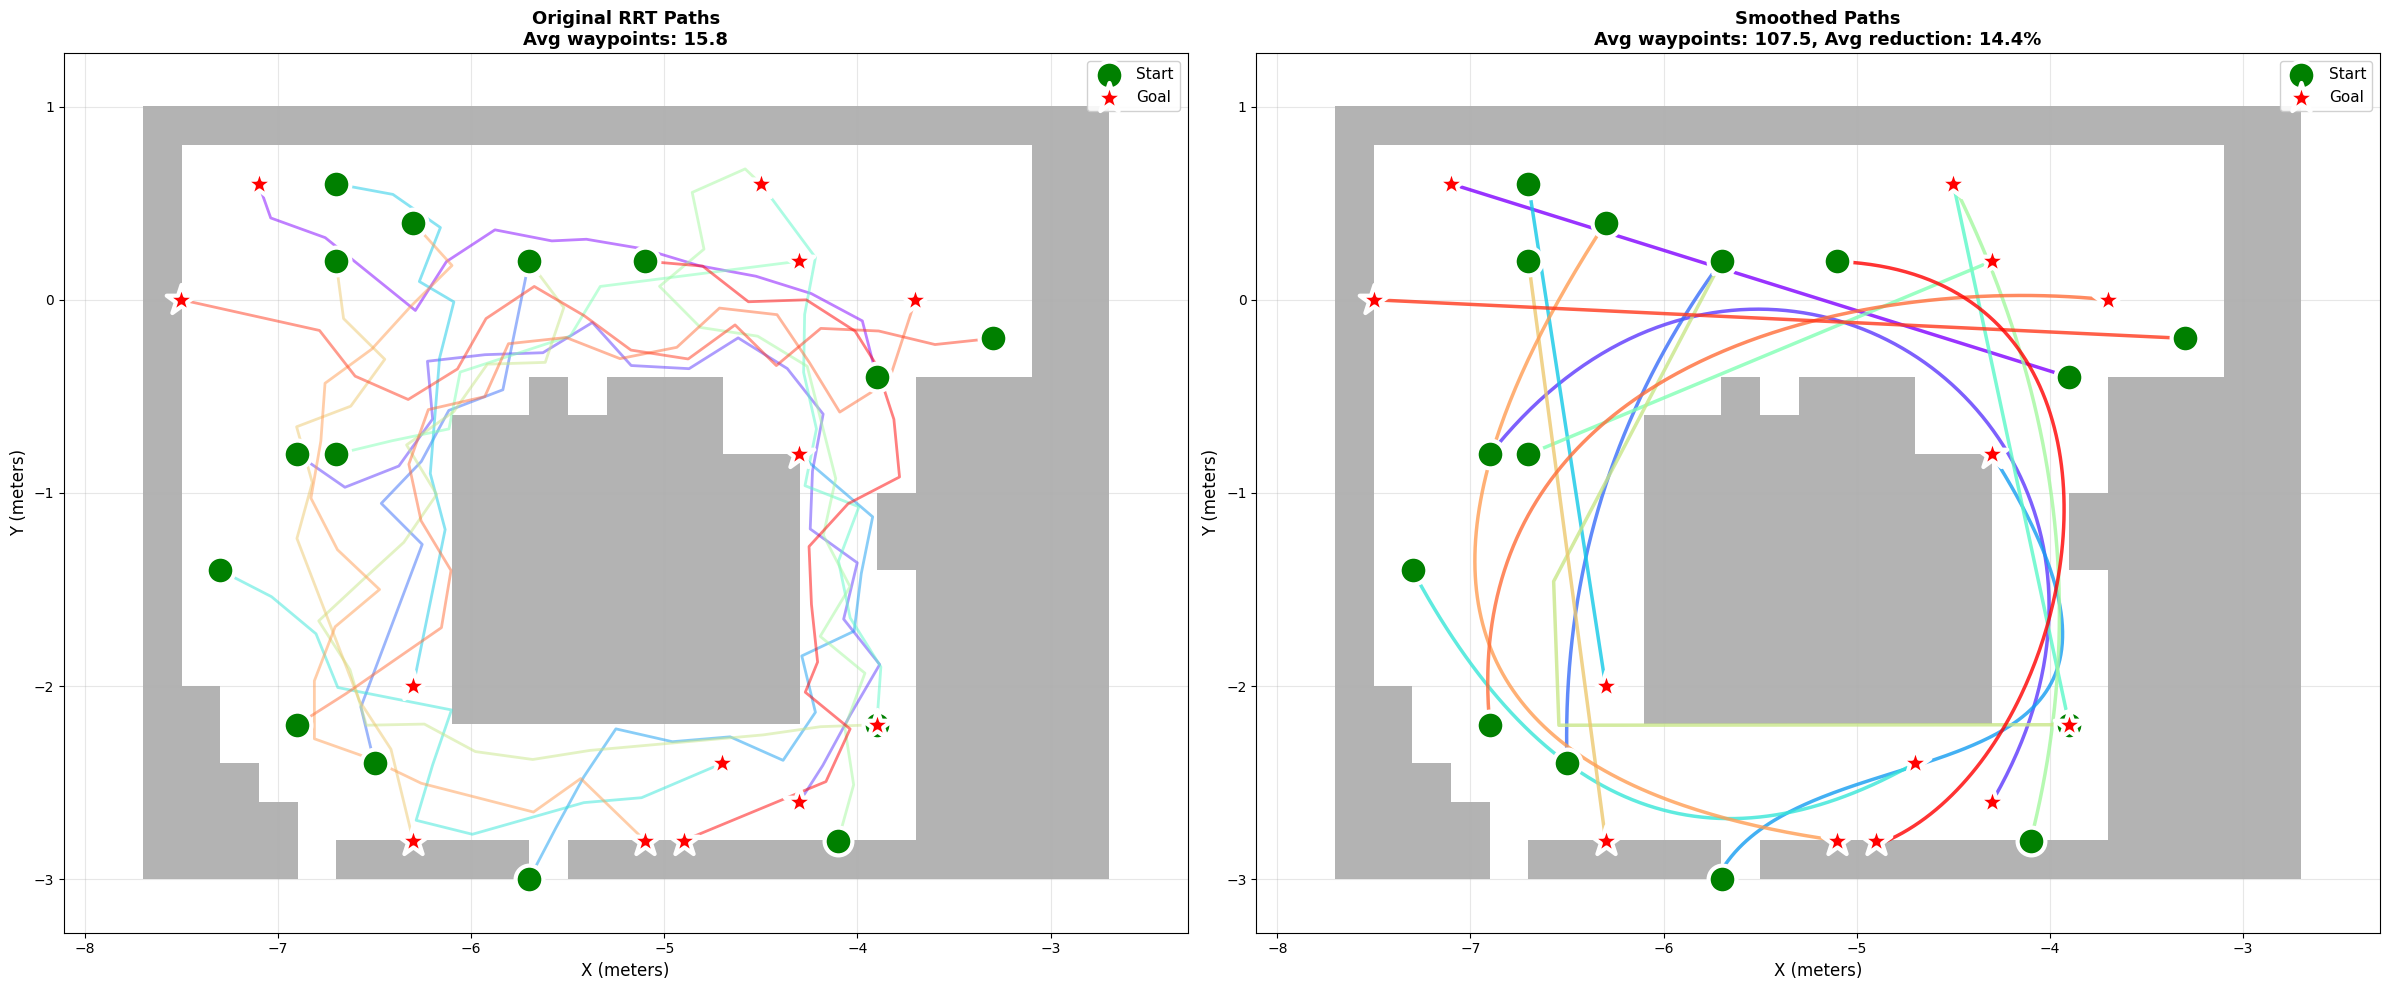

✓ Path comparison visualization complete


In [31]:
# Compare original vs smoothed paths side by side
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Left: Original RRT paths
ax = axes[0]
ax.imshow(occupancy_grid, cmap='gray_r', origin='lower', 
          extent=[X_MIN, X_MAX, Y_MIN, Y_MAX], 
          alpha=0.3, interpolation='nearest')

colors = plt.cm.rainbow(np.linspace(0, 1, len(smoothed_results)))
added_start = False
added_goal = False

for i, result in enumerate(smoothed_results):
    original_array = np.array(result['original_path'])
    ax.plot(original_array[:, 0], original_array[:, 1], 
            color=colors[i], linewidth=2, alpha=0.5)
    
    if not added_start:
        ax.scatter(result['start'][0], result['start'][1], 
                   c='green', s=400, marker='o', 
                   edgecolors='white', linewidths=3, zorder=10, label='Start')
        added_start = True
    else:
        ax.scatter(result['start'][0], result['start'][1], 
                   c='green', s=400, marker='o', 
                   edgecolors='white', linewidths=3, zorder=10)
    
    if not added_goal:
        ax.scatter(result['goal'][0], result['goal'][1], 
                   c='red', s=500, marker='*', 
                   edgecolors='white', linewidths=3, zorder=10, label='Goal')
        added_goal = True
    else:
        ax.scatter(result['goal'][0], result['goal'][1], 
                   c='red', s=500, marker='*', 
                   edgecolors='white', linewidths=3, zorder=10)

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel('X (meters)', fontsize=12)
ax.set_ylabel('Y (meters)', fontsize=12)
ax.set_title(f'Original RRT Paths\nAvg waypoints: {avg_original_waypoints:.1f}', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.axis('equal')

# Right: Smoothed paths
ax = axes[1]
ax.imshow(occupancy_grid, cmap='gray_r', origin='lower', 
          extent=[X_MIN, X_MAX, Y_MIN, Y_MAX], 
          alpha=0.3, interpolation='nearest')

added_start = False
added_goal = False

for i, result in enumerate(smoothed_results):
    smooth_array = np.array(result['smooth_path'])
    ax.plot(smooth_array[:, 0], smooth_array[:, 1], 
            color=colors[i], linewidth=2.5, alpha=0.8)
    
    if not added_start:
        ax.scatter(result['start'][0], result['start'][1], 
                   c='green', s=400, marker='o', 
                   edgecolors='white', linewidths=3, zorder=10, label='Start')
        added_start = True
    else:
        ax.scatter(result['start'][0], result['start'][1], 
                   c='green', s=400, marker='o', 
                   edgecolors='white', linewidths=3, zorder=10)
    
    if not added_goal:
        ax.scatter(result['goal'][0], result['goal'][1], 
                   c='red', s=500, marker='*', 
                   edgecolors='white', linewidths=3, zorder=10, label='Goal')
        added_goal = True
    else:
        ax.scatter(result['goal'][0], result['goal'][1], 
                   c='red', s=500, marker='*', 
                   edgecolors='white', linewidths=3, zorder=10)

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel('X (meters)', fontsize=12)
ax.set_ylabel('Y (meters)', fontsize=12)
ax.set_title(f'Smoothed Paths\nAvg waypoints: {avg_smooth_waypoints:.1f}, Avg reduction: {avg_reduction:.1f}%', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.axis('equal')

plt.tight_layout()
plt.show()

print("✓ Path comparison visualization complete")

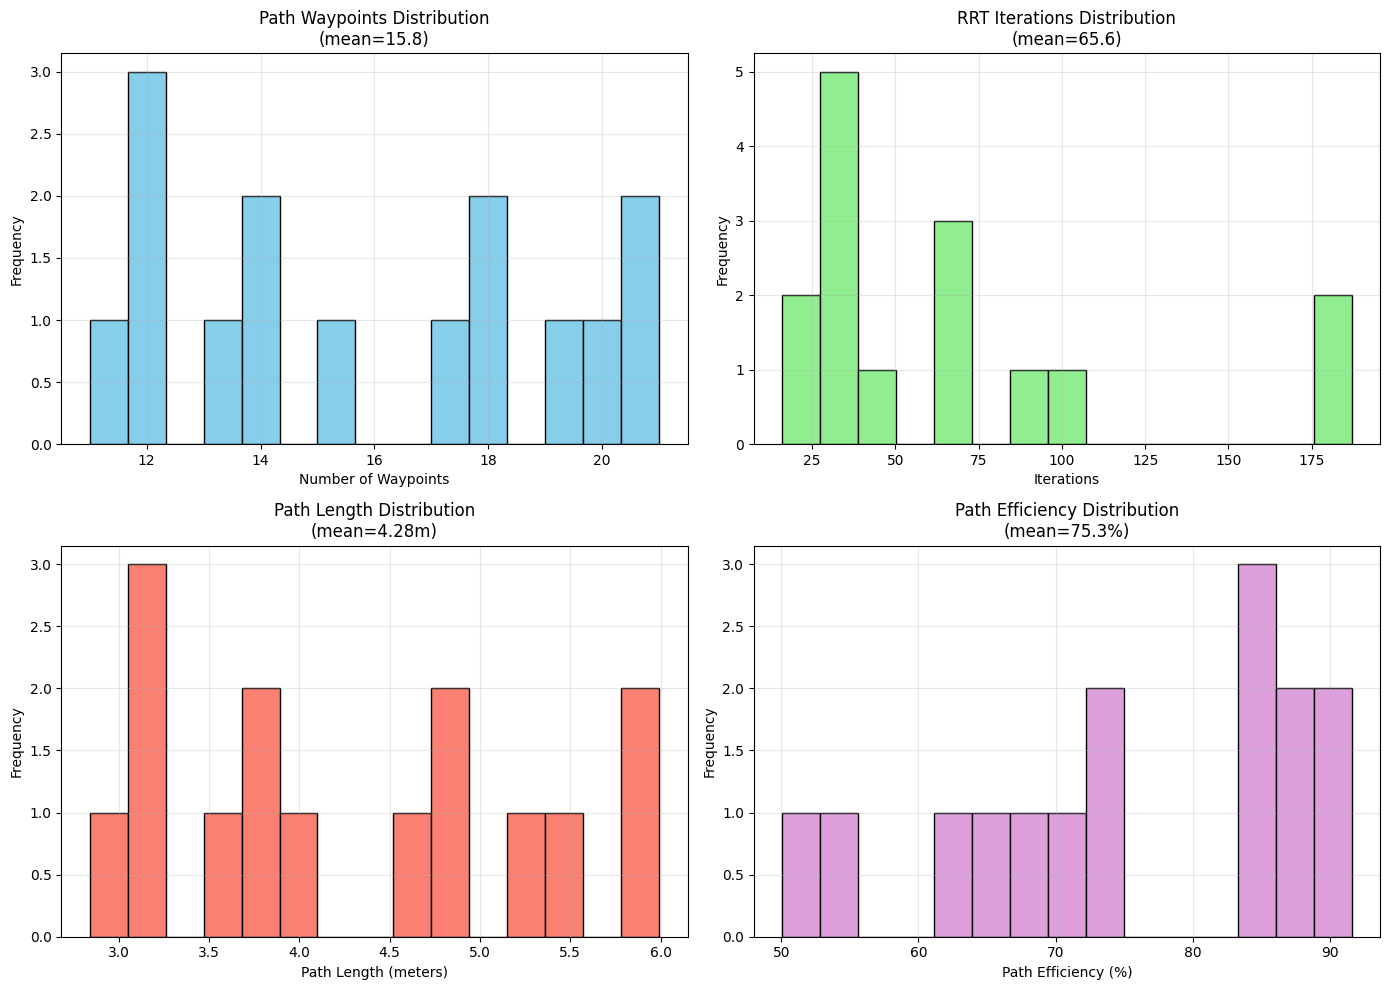

✓ Statistics visualization complete


In [32]:
if successful_tests:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Number of waypoints
    waypoint_counts = [r['num_waypoints'] for r in successful_tests]
    axes[0, 0].hist(waypoint_counts, bins=15, color='skyblue', edgecolor='black')
    axes[0, 0].set_xlabel('Number of Waypoints')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title(f'Path Waypoints Distribution\n(mean={np.mean(waypoint_counts):.1f})')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Iterations
    iteration_counts = [r['iterations'] for r in successful_tests]
    axes[0, 1].hist(iteration_counts, bins=15, color='lightgreen', edgecolor='black')
    axes[0, 1].set_xlabel('Iterations')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title(f'RRT Iterations Distribution\n(mean={np.mean(iteration_counts):.1f})')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Path length
    path_lengths = [r['path_length'] for r in successful_tests]
    axes[1, 0].hist(path_lengths, bins=15, color='salmon', edgecolor='black')
    axes[1, 0].set_xlabel('Path Length (meters)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title(f'Path Length Distribution\n(mean={np.mean(path_lengths):.2f}m)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Efficiency
    efficiencies = [r['efficiency'] * 100 for r in successful_tests]
    axes[1, 1].hist(efficiencies, bins=15, color='plum', edgecolor='black')
    axes[1, 1].set_xlabel('Path Efficiency (%)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title(f'Path Efficiency Distribution\n(mean={np.mean(efficiencies):.1f}%)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Statistics visualization complete")
else:
    print("No successful paths to analyze")

## Save Test Results

Save all test results to disk for later analysis.

In [33]:
# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = Path(f'../data/rrt_test_results_{timestamp}.npy')

# Prepare data for saving
save_data = {
    'timestamp': timestamp,
    'num_tests': len(results),
    'num_successful': len(successful_tests),
    'num_failed': len(failed_tests),
    'success_rate': len(successful_tests) / len(results) if results else 0,
    'results': results,
    'grid_bounds': (X_MIN, X_MAX, Y_MIN, Y_MAX),
    'rrt_params': {
        'step_size': rrt.step_size,
        'max_iterations': rrt.max_iterations,
        'goal_sample_rate': rrt.goal_sample_rate
    }
}

if successful_tests:
    save_data['statistics'] = {
        'avg_waypoints': np.mean([r['num_waypoints'] for r in successful_tests]),
        'avg_iterations': np.mean([r['iterations'] for r in successful_tests]),
        'avg_path_length': np.mean([r['path_length'] for r in successful_tests]),
        'avg_efficiency': np.mean([r['efficiency'] for r in successful_tests])
    }

np.save(output_file, save_data)

print("="*70)
print("Test Results Saved")
print("="*70)
print(f"File: {output_file}")
print(f"\nSummary:")
print(f"  Total tests: {len(results)}")
print(f"  Successful: {len(successful_tests)} ({len(successful_tests)/len(results)*100:.1f}%)")
print(f"  Failed: {len(failed_tests)} ({len(failed_tests)/len(results)*100:.1f}%)")
print("\n✓ Results saved successfully")

Test Results Saved
File: ../data/rrt_test_results_20251208_173310.npy

Summary:
  Total tests: 15
  Successful: 15 (100.0%)
  Failed: 0 (0.0%)

✓ Results saved successfully


## Output Individual Paths

Print detailed information for each successful path.

In [34]:
print("="*70)
print("Detailed Path Information")
print("="*70)

for result in successful_tests:
    print(f"\n{'='*70}")
    print(f"Test {result['test_id']}: Path Details")
    print(f"{'='*70}")
    print(f"Start: ({result['start'][0]:.3f}, {result['start'][1]:.3f})")
    print(f"Goal:  ({result['goal'][0]:.3f}, {result['goal'][1]:.3f})")
    print(f"\nMetrics:")
    print(f"  Waypoints: {result['num_waypoints']}")
    print(f"  Iterations: {result['iterations']}")
    print(f"  Path length: {result['path_length']:.3f}m")
    print(f"  Straight distance: {result['straight_distance']:.3f}m")
    print(f"  Efficiency: {result['efficiency']:.2%}")
    print(f"\nPath waypoints:")
    for i, waypoint in enumerate(result['path']):
        print(f"  {i+1:3d}. ({waypoint[0]:7.3f}, {waypoint[1]:7.3f})")

print(f"\n{'='*70}")
print("✓ All paths outputted")
print(f"{'='*70}")

Detailed Path Information

Test 1: Path Details
Start: (-3.900, -0.400)
Goal:  (-7.100, 0.600)

Metrics:
  Waypoints: 15
  Iterations: 66
  Path length: 3.966m
  Straight distance: 3.353m
  Efficiency: 84.53%

Path waypoints:
    1. ( -3.900,  -0.400)
    2. ( -3.975,  -0.109)
    3. ( -4.239,   0.032)
    4. ( -4.525,   0.122)
    5. ( -4.820,   0.177)
    6. ( -5.107,   0.263)
    7. ( -5.403,   0.313)
    8. ( -5.582,   0.305)
    9. ( -5.877,   0.362)
   10. ( -6.128,   0.198)
   11. ( -6.289,  -0.055)
   12. ( -6.522,   0.133)
   13. ( -6.755,   0.322)
   14. ( -7.037,   0.424)
   15. ( -7.100,   0.600)

Test 2: Path Details
Start: (-6.900, -0.800)
Goal:  (-4.300, -2.600)

Metrics:
  Waypoints: 21
  Iterations: 64
  Path length: 5.924m
  Straight distance: 3.162m
  Efficiency: 53.38%

Path waypoints:
    1. ( -6.900,  -0.800)
    2. ( -6.653,  -0.971)
    3. ( -6.374,  -0.861)
    4. ( -6.199,  -0.617)
    5. ( -6.226,  -0.318)
    6. ( -5.928,  -0.284)
    7. ( -5.628,  -0.274)
 